In [1]:
import sys
from pathlib import Path

ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

import pandas as pd
import numpy as np

In [2]:
from models.walkforward.walkforward_runner import load_gold_dataset, prepare_features_and_target

df = load_gold_dataset()
X, y = prepare_features_and_target(df)

print(df.shape)
print(X.shape)
print(y.shape)
print(df.index.min(), df.index.max())

(62764, 13)
(62764, 6)
(62764,)
2019-01-01 12:00:00 2026-03-03 03:00:00


In [3]:
from models.walkforward.walkforward_runner import generate_expanding_windows

windows = generate_expanding_windows(df)

print("Total windows:", len(windows))

for i, w in enumerate(windows):
    print(i+1, w)

Total windows: 8
1 {'train_start': Timestamp('2019-01-01 12:00:00'), 'train_end': Timestamp('2022-01-01 12:00:00'), 'test_start': Timestamp('2022-01-01 12:00:00'), 'test_end': Timestamp('2022-07-01 12:00:00')}
2 {'train_start': Timestamp('2019-01-01 12:00:00'), 'train_end': Timestamp('2022-07-01 12:00:00'), 'test_start': Timestamp('2022-07-01 12:00:00'), 'test_end': Timestamp('2023-01-01 12:00:00')}
3 {'train_start': Timestamp('2019-01-01 12:00:00'), 'train_end': Timestamp('2023-01-01 12:00:00'), 'test_start': Timestamp('2023-01-01 12:00:00'), 'test_end': Timestamp('2023-07-01 12:00:00')}
4 {'train_start': Timestamp('2019-01-01 12:00:00'), 'train_end': Timestamp('2023-07-01 12:00:00'), 'test_start': Timestamp('2023-07-01 12:00:00'), 'test_end': Timestamp('2024-01-01 12:00:00')}
5 {'train_start': Timestamp('2019-01-01 12:00:00'), 'train_end': Timestamp('2024-01-01 12:00:00'), 'test_start': Timestamp('2024-01-01 12:00:00'), 'test_end': Timestamp('2024-07-01 12:00:00')}
6 {'train_start': 

In [4]:
from models.walkforward.walkforward_runner import split_window

X, y = prepare_features_and_target(df)

w0 = windows[0]

X_train, y_train, X_test, y_test = split_window(X, y, w0)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("Train range:", X_train.index.min(), "->", X_train.index.max())
print("Test range:", X_test.index.min(), "->", X_test.index.max())

Train shape: (26245, 6)
Test shape: (4344, 6)
Train range: 2019-01-01 12:00:00 -> 2022-01-01 11:00:00
Test range: 2022-01-01 12:00:00 -> 2022-07-01 11:00:00


In [5]:
from models.walkforward.walkforward_runner import scale_window

X_train_s, X_test_s, scaler = scale_window(X_train, X_test)

print(X_train_s.shape, X_test_s.shape)

(26245, 6) (4344, 6)


In [6]:
from models.walkforward.walkforward_runner import get_model

m1 = get_model("logistic")
m2 = get_model("rf")
m3 = get_model("xgb")

print(type(m1), type(m2), type(m3))

<class 'sklearn.linear_model._logistic.LogisticRegression'> <class 'sklearn.ensemble._forest.RandomForestClassifier'> <class 'xgboost.sklearn.XGBClassifier'>


In [7]:
from models.walkforward.walkforward_runner import (
    load_gold_dataset,
    prepare_features_and_target,
    generate_expanding_windows,
    split_window,
    scale_window,
    train_and_evaluate_single_window,
)

df = load_gold_dataset()
X, y = prepare_features_and_target(df)
windows = generate_expanding_windows(df)

print("Total windows:", len(windows))

Total windows: 8


In [8]:
w0 = windows[0]

for model_name in ["logistic", "rf", "xgb"]:
    
    res = train_and_evaluate_single_window(
        X,
        y,
        w0,
        model_name=model_name,
    )
    
    print("----", model_name.upper(), "----")
    print("Accuracy:", round(res["accuracy"], 4))
    print("AUC:", round(res["auc"], 4))
    print()

---- LOGISTIC ----
Accuracy: 0.5131
AUC: 0.533

---- RF ----
Accuracy: 0.5373
AUC: 0.5549

---- XGB ----
Accuracy: 0.5274
AUC: 0.5406



In [ ]:
from models.walkforward.walkforward_runner import run_walkforward_for_model

for model_name in ["logistic", "rf", "xgb"]:

    df_model, equity_curve, returns = run_walkforward_for_model(
        X,
        y,
        df,       
        windows,
        model_name=model_name,
        threshold=0.5,
        save_results=True,
    )

    print(model_name.upper())
    print(df_model[["window", "auc", "sharpe"]])
    print()

LOGISTIC
   window       auc    sharpe
0       1  0.533042 -3.648923
1       2  0.544265 -0.409037
2       3  0.560355  1.975275
3       4  0.555880  3.761907
4       5  0.538016  2.359901
5       6  0.536696  3.589215
6       7  0.539597  2.320543
7       8  0.523209 -1.501403

RF
   window       auc    sharpe
0       1  0.554893 -2.756892
1       2  0.551914 -1.075197
2       3  0.563834  2.801963
3       4  0.570456  2.604373
4       5  0.548380  2.641957
5       6  0.542779  5.028145
6       7  0.536857  2.012030
7       8  0.540325 -0.709980

XGB
   window       auc    sharpe
0       1  0.540553 -2.950207
1       2  0.549486 -0.296203
2       3  0.551117  3.252696
3       4  0.559133  2.738175
4       5  0.547972  2.857541
5       6  0.539184  4.060974
6       7  0.528659  1.330026
7       8  0.539061 -0.936226



In [ ]:
for model_name in ["logistic", "rf", "xgb"]:

    df_model, equity_curve, returns = run_walkforward_for_model(
        X,
        y,
        df, 
        windows,
        model_name=model_name,
        threshold=0.5,
        save_results=True,
    )

    print(model_name.upper())
    print("Mean Sharpe:", df_model["sharpe"].mean())
    print("Std Sharpe:", df_model["sharpe"].std())
    print("Windows Sharpe < 0:", (df_model["sharpe"] < 0).sum())

LOGISTIC
Mean Sharpe: 1.055934558460087
Std Sharpe: 2.6378114499824616
Windows Sharpe < 0: 3
RF
Mean Sharpe: 1.3182999773348905
Std Sharpe: 2.5718658072301768
Windows Sharpe < 0: 3
XGB
Mean Sharpe: 1.257096856726524
Std Sharpe: 2.4357247391662145
Windows Sharpe < 0: 3


In [19]:
for model_name in ["logistic", "rf", "xgb"]:

    df_model, equity_curve, returns = run_walkforward_for_model(
        X,
        y,
        df,        
        windows,
        model_name=model_name,
        threshold=0.5,
        save_results=True,
    )

    print(model_name.upper())   
    print(len(equity_curve))
    print(equity_curve[-5:])

LOGISTIC
35063
[2.71275872 2.72060113 2.72283047 2.72465512 2.72287252]
RF
35063
[5.37035777 5.37035777 5.37035777 5.37035777 5.37035777]
XGB
35063
[5.10976804 5.10976804 5.10976804 5.10976804 5.10976804]


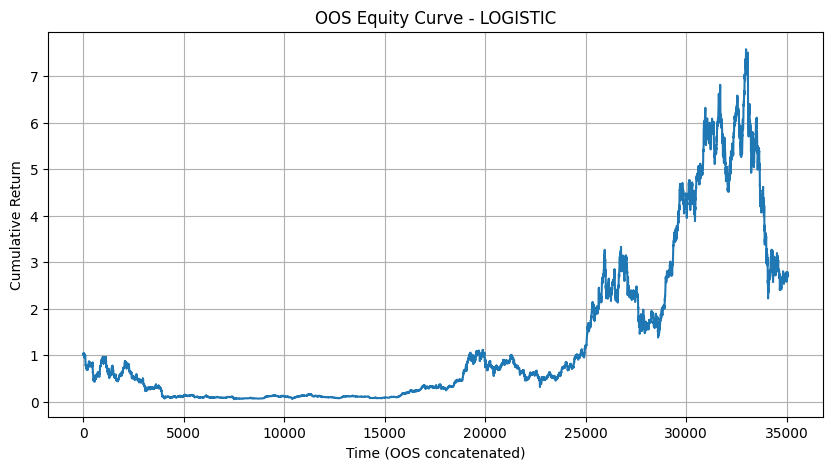

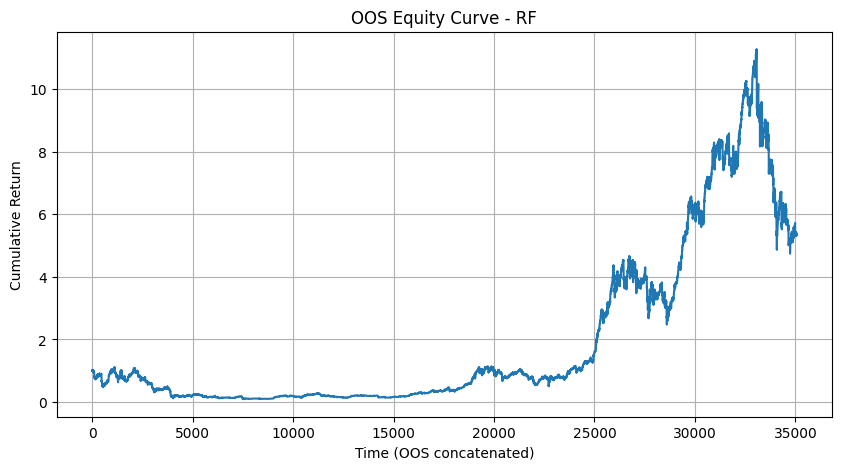

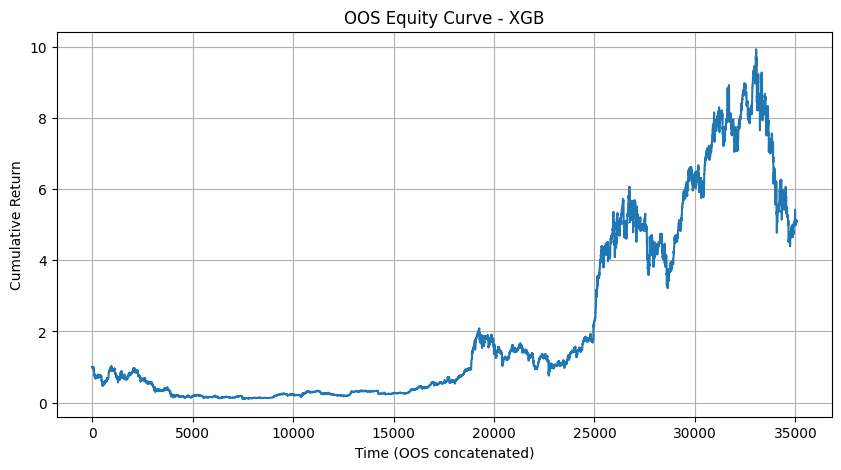

In [20]:
import matplotlib.pyplot as plt

for model_name in ["logistic", "rf", "xgb"]:

    df_model, equity_curve, returns = run_walkforward_for_model(
        X,
        y,
        df,
        windows,
        model_name=model_name,
        threshold=0.5,
        save_results=True,
    )

    plt.figure(figsize=(10,5))
    plt.plot(equity_curve)
    plt.title(f"OOS Equity Curve - {model_name.upper()}")
    plt.xlabel("Time (OOS concatenated)")
    plt.ylabel("Cumulative Return")
    plt.grid(True)
    plt.show()

In [ ]:
for model_name in ["logistic", "rf", "xgb"]:

    df_model, equity_curve, returns = run_walkforward_for_model(
        X,
        y,
        df,       
        windows,
        model_name=model_name,
        threshold=0.5,
        save_results=True,
    )

    mean_ret = returns.mean()
    std_ret = returns.std()
    sharpe_global = (mean_ret / std_ret) * np.sqrt(365*24)

    print(model_name.upper())   
    print(sharpe_global)

LOGISTIC
0.7112731164529856
RF
0.9519868368941152
XGB
0.9352702698259563


In [ ]:
from scipy.stats import linregress

for model_name in ["logistic", "rf", "xgb"]:

    df_model, equity_curve, returns = run_walkforward_for_model(
        X,
        y,
        df,      
        windows,
        model_name=model_name,
        threshold=0.5,
        save_results=True,
    )

    slope_auc = linregress(df_model["window"], df_model["auc"]).slope
    slope_sharpe = linregress(df_model["window"], df_model["sharpe"]).slope

    print(model_name.upper())       
    print("AUC slope:", slope_auc)
    print("Sharpe slope:", slope_sharpe)

LOGISTIC
AUC slope: -0.0021549034460200175
Sharpe slope: 0.3823851564155368
RF
AUC slope: -0.003124991798124469
Sharpe slope: 0.4342934470401881
XGB
AUC slope: -0.0019231362064017594
Sharpe slope: 0.2949191933150593
